# 3D Richards Solver Example (Regular Grid)

This notebook demonstrates how to use `Richards3DModifiedPicard` from `richards_3d_modified_picard.py` on a regular grid.

Regular-grid/domain settings are taken from the last regular-grid example in `Examples.ipynb`:
- planform: `rows=7`, `cols=6`
- layers: `n_layers=5`, `dz=0.04 m`
- bottom elevation reference: `z_base=10.1 m`
- rainfall target IDs: `[10, 4, 5, 11]`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from richards_3d_modified_picard import Richards3DModifiedPicard

In [2]:
# --- Shared physical parameters from Examples.ipynb ---
alpha = 0.067 * 100
n_vg = 2
theta_r = 0.075
theta_s = 0.287
Ks = 100 / 100 / 3600
S_s = 1e-10
rainfall_intensity = 0.1 / 100 / 86400  # m/s

# --- Regular grid/domain properties from last regular-grid example ---
rows, cols = 7, 6
n_layers = 5
dz = 0.04
z_base = 10.1  # explicit bottom-layer elevation [m]

# Regular grid cell dimensions (unit squares used in Examples geometry plots)
dx = 1.0
dy = 1.0

# Rain applied only on these top-surface cell IDs
rain_ids = [10, 4, 5, 11]

solver = Richards3DModifiedPicard(
    nx=cols,
    ny=rows,
    nz=n_layers,
    dx=dx,
    dy=dy,
    dz=dz,
    z_base=z_base,
    alpha=alpha,
    n_vg=n_vg,
    theta_r=theta_r,
    theta_s=theta_s,
    Ks=Ks,
    S_s=S_s,
)

print(f"Grid: nx={solver.nx}, ny={solver.ny}, nz={solver.nz}, total_cells={solver.n}")
print(f"Bottom elevation reference z_base={z_base} m")

Grid: nx=6, ny=7, nz=5, total_cells=210
Bottom elevation reference z_base=10.1 m


In [3]:
# Build a top-flux field (ny x nx), matching rain_ids from the prism indexing i = row*cols + col
top_flux = np.zeros((rows, cols), dtype=float)
for pid in rain_ids:
    r = pid // cols
    c = pid % cols
    top_flux[r, c] = rainfall_intensity

# Initial condition and time controls
h0 = np.full(solver.n, -10.0)
dt = 864.0
steps = 1000

history = solver.solve_transient(
    h0=h0,
    dt=dt,
    n_steps=steps,
    top_flux=top_flux,
    max_iter=100,
    tol=1e-5,
)

h_final = history[-1]
print("Simulation complete")
print("Final head min/max:", float(h_final.min()), float(h_final.max()))

Simulation complete
Final head min/max: -10.021758777005918 -0.41477471179513237


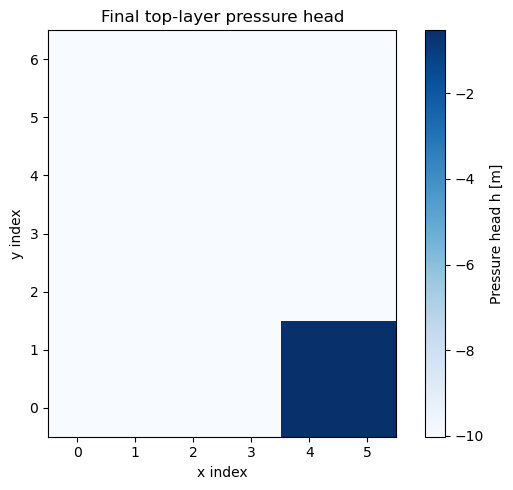

In [4]:
# Visualize top-layer pressure head at final time
h_final_3d = h_final.reshape((n_layers, rows, cols))
top_layer = h_final_3d[-1]

plt.figure(figsize=(6, 5))
im = plt.imshow(top_layer, origin='lower', cmap='Blues')
plt.colorbar(im, label='Pressure head h [m]')
plt.title('Final top-layer pressure head')
plt.xlabel('x index')
plt.ylabel('y index')
plt.tight_layout()
plt.show()

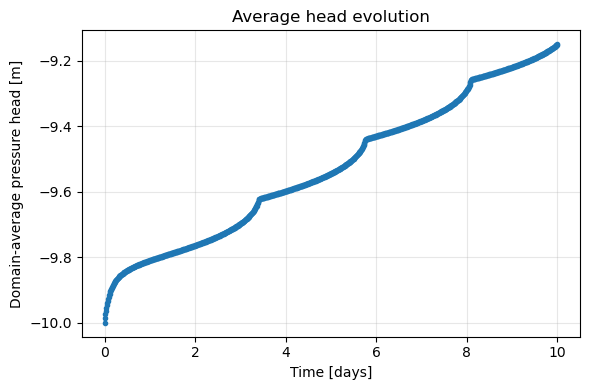

In [5]:
# Optional: quick 1D-in-time diagnostic of domain-average head
avg_head = history.mean(axis=1)
t_days = np.arange(history.shape[0]) * dt / 86400.0

plt.figure(figsize=(6, 4))
plt.plot(t_days, avg_head, '-o', ms=3)
plt.xlabel('Time [days]')
plt.ylabel('Domain-average pressure head [m]')
plt.title('Average head evolution')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Side-by-side comparison with legacy regular-grid solver

This block reproduces a regular-grid run using the original `RichardsSolver` (`richards_model.py`) and compares integrated metrics against the new 3D modified-Picard solver for the same physical setup.

In [6]:
import numpy as np
from richards_model import RichardsSolver
from richards_3d_modified_picard import Richards3DModifiedPicard


def generate_regular_grid(rows, cols, cell_size=1.0):
    adj = {}
    areas = {}
    widths = {}
    lengths = {}

    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            neighbors = []

            if c > 0:
                neighbors.append(i - 1)
            if c < cols - 1:
                neighbors.append(i + 1)
            if r > 0:
                neighbors.append(i - cols)
            if r < rows - 1:
                neighbors.append(i + cols)

            adj[i] = neighbors
            areas[i] = cell_size * cell_size

    n = rows * cols
    for i in range(n):
        widths[i] = [0.0] * n
        lengths[i] = [0.0] * n
        for j in adj[i]:
            widths[i][j] = cell_size
            lengths[i][j] = cell_size

    return adj, areas, widths, lengths


def mass_balance_from_flux_series(storage_change, q_series, dt):
    cumulative_inflow = 0.0
    for q in q_series:
        cumulative_inflow += float(q) * float(dt)
    abs_mass_error = abs(float(storage_change) - cumulative_inflow)
    return cumulative_inflow, abs_mass_error


def run_legacy_metrics(rows, cols, n_layers, dz, alpha, n_vg, theta_r, theta_s, Ks, S_s,
                       rainfall_intensity, rain_ids, dt, steps, z_base, h0_value=-10.0):
    adj, areas, widths, lengths = generate_regular_grid(rows, cols, cell_size=1.0)
    n_prisms = rows * cols

    legacy_solver = RichardsSolver(
        alpha=alpha,
        n_vg=n_vg,
        theta_r=np.full((n_prisms, n_layers), theta_r),
        theta_s=np.full((n_prisms, n_layers), theta_s),
        Ks=np.full((n_prisms, n_layers), Ks),
        S_s=S_s,
        dz=np.full(n_layers, dz),
        base_elevations=np.full(n_prisms, z_base),
        rainfall_intensity=rainfall_intensity,
        rainfall_prisms=rain_ids,
        adj_prisms=adj,
        A_ij=areas,
        W_ij=widths,
        L_ij=lengths,
    )

    h = np.full(legacy_solver.total_cells, h0_value)
    s0 = legacy_solver.calculate_storage(h)
    q_series = []

    for _ in range(steps):
        q_in = legacy_solver.get_boundary_flux_with_rain(h)
        q_series.append(q_in)
        h = legacy_solver.solve_step(h, dt)

    s_end = legacy_solver.calculate_storage(h)
    storage_change = s_end - s0
    cumulative_inflow, abs_mass_error = mass_balance_from_flux_series(storage_change, q_series, dt)

    return {
        'final_h_min': float(np.min(h)),
        'final_h_max': float(np.max(h)),
        'storage_change': float(storage_change),
        'cumulative_inflow': float(cumulative_inflow),
        'abs_mass_error': float(abs_mass_error),
    }


def run_new3d_metrics(rows, cols, n_layers, dz, alpha, n_vg, theta_r, theta_s, Ks, S_s,
                      top_flux, dt, steps, z_base, h0_value=-10.0):
    solver_3d = Richards3DModifiedPicard(
        nx=cols,
        ny=rows,
        nz=n_layers,
        dx=1.0,
        dy=1.0,
        dz=dz,
        z_base=z_base,
        alpha=alpha,
        n_vg=n_vg,
        theta_r=theta_r,
        theta_s=theta_s,
        Ks=Ks,
        S_s=S_s,
    )

    h = np.full(solver_3d.n, h0_value)
    theta0 = solver_3d.theta(h.reshape((solver_3d.nz, solver_3d.ny, solver_3d.nx)))
    s0 = float(np.sum(theta0) * solver_3d.cell_volume)

    q_in_const = float(np.sum(top_flux) * solver_3d.dx * solver_3d.dy)
    q_series = [q_in_const] * int(steps)

    for _ in range(steps):
        h = solver_3d.solve_step(h, dt=dt, top_flux=top_flux, max_iter=60, tol=1e-5)

    h3 = h.reshape((solver_3d.nz, solver_3d.ny, solver_3d.nx))
    theta_end = solver_3d.theta(h3)
    s_end = float(np.sum(theta_end) * solver_3d.cell_volume)

    storage_change = s_end - s0
    cumulative_inflow, abs_mass_error = mass_balance_from_flux_series(storage_change, q_series, dt)

    return {
        'final_h_min': float(np.min(h)),
        'final_h_max': float(np.max(h)),
        'storage_change': float(storage_change),
        'cumulative_inflow': float(cumulative_inflow),
        'abs_mass_error': float(abs_mass_error),
    }


legacy_metrics = run_legacy_metrics(
    rows=rows,
    cols=cols,
    n_layers=n_layers,
    dz=dz,
    alpha=alpha,
    n_vg=n_vg,
    theta_r=theta_r,
    theta_s=theta_s,
    Ks=Ks,
    S_s=S_s,
    rainfall_intensity=rainfall_intensity,
    rain_ids=rain_ids,
    dt=dt,
    steps=steps,
    z_base=z_base,
)

new3d_metrics = run_new3d_metrics(
    rows=rows,
    cols=cols,
    n_layers=n_layers,
    dz=dz,
    alpha=alpha,
    n_vg=n_vg,
    theta_r=theta_r,
    theta_s=theta_s,
    Ks=Ks,
    S_s=S_s,
    top_flux=top_flux,
    dt=dt,
    steps=steps,
    z_base=z_base,
)

print('Metric comparison (legacy vs new 3D)')
print('-' * 72)
print(f"{'metric':<22}{'legacy':>20}{'new_3d':>20}")
print('-' * 72)
for key in ['final_h_min', 'final_h_max', 'storage_change', 'cumulative_inflow', 'abs_mass_error']:
    print(f"{key:<22}{legacy_metrics[key]:>20.8e}{new3d_metrics[key]:>20.8e}")
print('-' * 72)

Metric comparison (legacy vs new 3D)
------------------------------------------------------------------------
metric                              legacy              new_3d
------------------------------------------------------------------------
final_h_min                -1.00217588e+01     -1.00217588e+01
final_h_max                -4.14772232e-01     -4.14774712e-01
storage_change              4.00000017e-02      4.00000000e-02
cumulative_inflow           4.00000000e-02      4.00000000e-02
abs_mass_error              1.73877623e-09      1.67578104e-11
------------------------------------------------------------------------


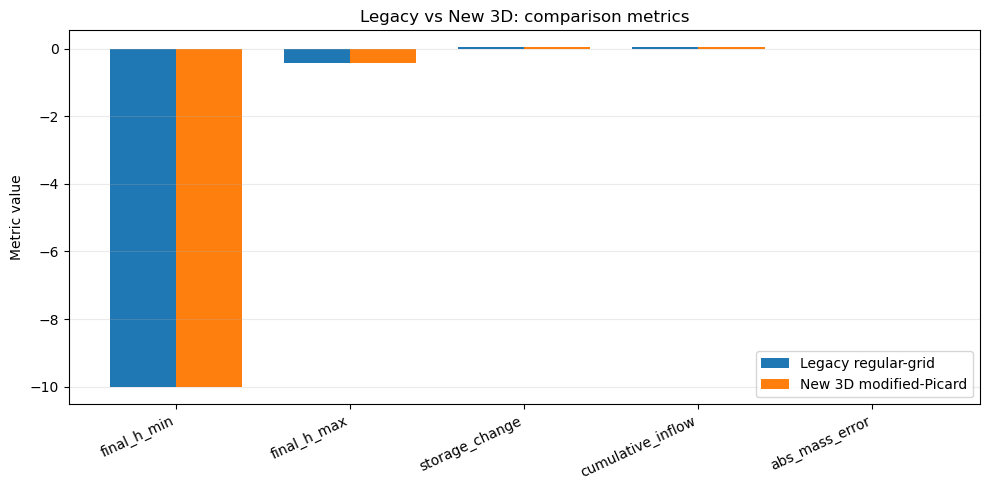

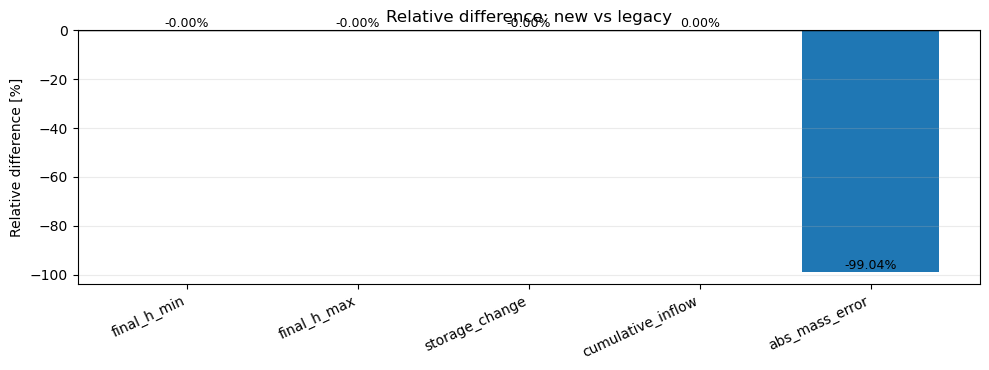

In [7]:
# Cell 9: Bar-plot of metric differences (legacy vs new 3D)
import numpy as np
import matplotlib.pyplot as plt

required = ['legacy_metrics', 'new3d_metrics']
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(f"Run Cell 8 first. Missing variables: {missing}")

metrics = ['final_h_min', 'final_h_max', 'storage_change', 'cumulative_inflow', 'abs_mass_error']
legacy_vals = np.array([legacy_metrics[m] for m in metrics], dtype=float)
new_vals = np.array([new3d_metrics[m] for m in metrics], dtype=float)

x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, legacy_vals, width=w, label='Legacy regular-grid')
ax.bar(x + w/2, new_vals, width=w, label='New 3D modified-Picard')

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=25, ha='right')
ax.set_ylabel('Metric value')
ax.set_title('Legacy vs New 3D: comparison metrics')
ax.grid(True, axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Optional normalized difference plot: (new - legacy) / max(|legacy|, eps)
eps = 1e-20
rel_diff_pct = 100.0 * (new_vals - legacy_vals) / np.maximum(np.abs(legacy_vals), eps)

plt.figure(figsize=(10, 3.8))
bars = plt.bar(metrics, rel_diff_pct)
plt.axhline(0.0, color='k', linewidth=1)
plt.ylabel('Relative difference [%]')
plt.title('Relative difference: new vs legacy')
plt.xticks(rotation=25, ha='right')
plt.grid(True, axis='y', alpha=0.25)

for b, v in zip(bars, rel_diff_pct):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()